In [1]:
"""
Dont run this multiple times. If you downloaded the dataset, you don't need to download it again.

import kagglehub

# Download latest version
path = kagglehub.dataset_download("techsash/waste-classification-data")

print("Path to dataset files:", path)

"""

'\nDont run this multiple times. If you downloaded the dataset, you don\'t need to download it again.\n\nimport kagglehub\n\n# Download latest version\npath = kagglehub.dataset_download("techsash/waste-classification-data")\n\nprint("Path to dataset files:", path)\n\n'

In [1]:
import kagglehub
print("EcoSort is working!")
print("KaggleHub works!")

EcoSort is working!
KaggleHub works!


e:\AaSchool\MAPUA\6th year\1st Qtr\CPE178P\Final Project\EcoSort\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
"""
Why is there redundant code here?

path = kagglehub.dataset_download("techsash/waste-classification-data")
print(path)
"""

'\nWhy is there redundant code here?\n\npath = kagglehub.dataset_download("techsash/waste-classification-data")\nprint(path)\n'

In [3]:
import os
cwd = os.getcwd()
print("Current working directory:", cwd)

Current working directory: e:\AaSchool\MAPUA\6th year\1st Qtr\CPE178P\Final Project


In [4]:
path = r"e:\AaSchool\MAPUA\6th year\1st Qtr\CPE178P\Final Project\waste-classification-data\versions\1"
print(os.listdir(path))

['DATASET']


In [5]:
print(os.listdir(os.path.join(path, "DATASET")))

['DATASET', 'TEST', 'TRAIN']


In [6]:
print(os.listdir(os.path.join(path, "dataset", "TRAIN")))

['O', 'R']


In [7]:
for category in ["O", "R"]:
    folder = os.path.join(path, "dataset", "TRAIN", category)
    print(category, ":", len(os.listdir(folder)), "files")
    print(os.listdir(folder)[:5])

O : 12565 files
['O_1.jpg', 'O_10.jpg', 'O_100.jpg', 'O_1000.jpg', 'O_10000.jpg']
R : 9999 files
['R_1.jpg', 'R_10.jpg', 'R_100.jpg', 'R_1000.jpg', 'R_1001.jpg']


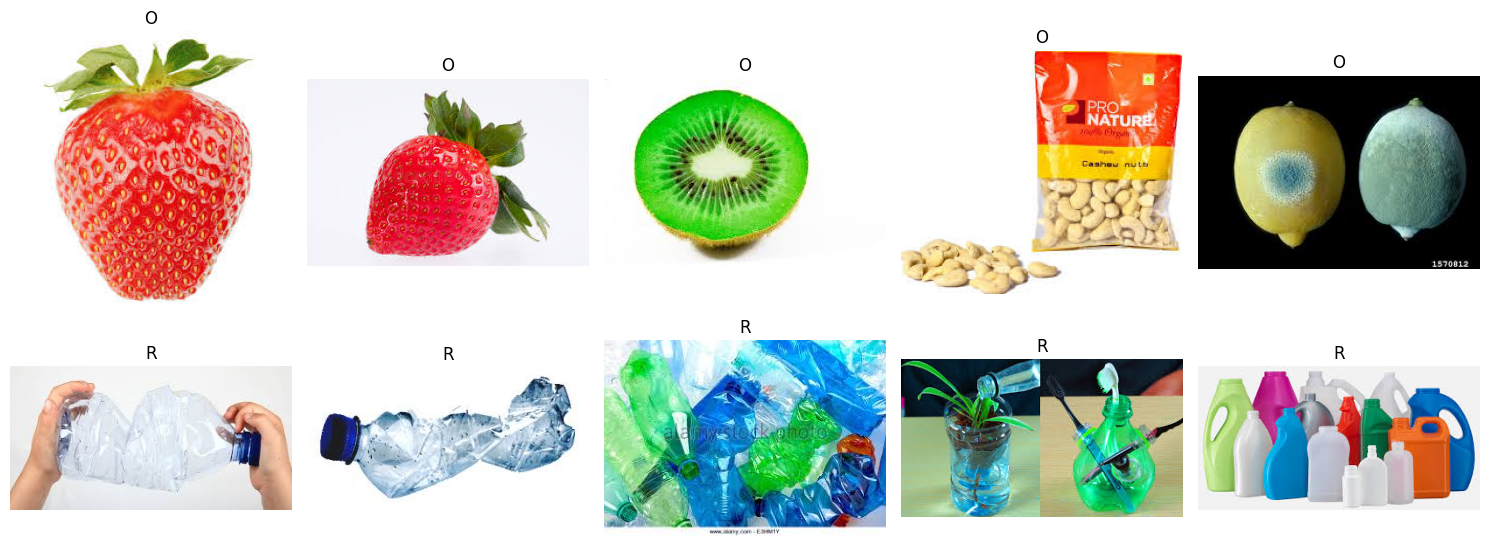

In [8]:
from PIL import Image
import matplotlib.pyplot as plt

train_path = os.path.join(path, "dataset", "TRAIN")

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for row, category in enumerate(["O", "R"]):
    folder = os.path.join(train_path, category)
    files = os.listdir(folder)[:5]

    for col, filename in enumerate(files):
        img = Image.open(os.path.join(folder, filename))

        axes[row, col].imshow(img)
        axes[row, col].set_title(category)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

In [9]:
print(os.listdir(os.path.join(path, "dataset", "TEST")))

['O', 'R']


In [10]:
for category in ["O", "R"]:
    folder = os.path.join(path, "dataset", "TEST", category)
    print(category, ":", len(os.listdir(folder)), "files")

O : 1401 files
R : 1112 files


In [11]:
print(os.listdir(os.path.join(path, "dataset", "DATASET")))

['TEST', 'TRAIN']


In [12]:
sample_path = os.path.join(
    path, "dataset", "TRAIN", "O", "O_1.jpg"
)

img = Image.open(sample_path)

print("Image size:", img.size)
print("Image mode:", img.mode)

Image size: (208, 242)
Image mode: RGB


In [13]:
train_path = os.path.join(path, "dataset", "TRAIN")

for category in ["O", "R"]:
    folder = os.path.join(train_path, category)
    sample = os.listdir(folder)[0]
    img = Image.open(os.path.join(folder, sample))
    print(category, sample, img.size, img.mode)

O O_1.jpg (208, 242) RGB
R R_1.jpg (314, 160) RGB


In [14]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_dir = os.path.join(path, "dataset", "TRAIN")
test_dir = os.path.join(path, "dataset", "TEST")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_data = datasets.ImageFolder(train_dir, transform=transform)
test_data = datasets.ImageFolder(test_dir, transform=transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

print("Classes:", train_data.classes)
print("Training images:", len(train_data))
print("Testing images:", len(test_data))

Classes: ['O', 'R']
Training images: 22564
Testing images: 2513


In [15]:
import torch
from torch.utils.data import random_split

train_size = int(0.85 * len(train_data))
val_size = len(train_data) - train_size

train_subset, val_subset = random_split(
    train_data,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=32, shuffle=False)

print("Training:", len(train_subset))
print("Validation:", len(val_subset))
print("Testing:", len(test_data))

Training: 19179
Validation: 3385
Testing: 2513


In [16]:
import torch.nn as nn
from torchvision import models

# Load pretrained EfficientNet-B0
model = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.DEFAULT
)

# Replace the final layer for 2 classes: Organic and Recyclable
model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    2
)

print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=2, bias=True)
)


In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

print("Device:", device)

Device: cuda


In [18]:
# Freeze the EfficientNet feature extractor
for param in model.features.parameters():
    param.requires_grad = False

# Make sure only the classifier is trainable
for param in model.classifier.parameters():
    param.requires_grad = True

# Recreate optimizer for the trainable parameters only
optimizer = torch.optim.Adam(
    model.classifier.parameters(),
    lr=0.001
)

print("Trainable parameters:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

Trainable parameters:
classifier.1.weight
classifier.1.bias


In [19]:
from torch.utils.data import Subset

# Use 3,000 training images and 500 validation images for now
small_train = Subset(train_subset, range(3000))
small_val = Subset(val_subset, range(500))

train_loader = DataLoader(
    small_train,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    small_val,
    batch_size=32,
    shuffle=False
)

print("Training:", len(small_train))
print("Validation:", len(small_val))

Training: 3000
Validation: 500


In [20]:
num_epochs = 1

model.train()
running_loss = 0.0
correct = 0
total = 0

for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)

    optimizer.zero_grad()

    outputs = model(images)
    loss = criterion(outputs, labels)

    loss.backward()
    optimizer.step()

    running_loss += loss.item()

    _, predicted = torch.max(outputs, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

train_accuracy = 100 * correct / total

print(f"Loss: {running_loss/len(train_loader):.4f}")
print(f"Training Accuracy: {train_accuracy:.2f}%")

Loss: 0.3966
Training Accuracy: 83.87%


In [21]:
model.eval()

val_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        val_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

val_accuracy = 100 * correct / total

print(f"Validation Loss: {val_loss/len(val_loader):.4f}")
print(f"Validation Accuracy: {val_accuracy:.2f}%")

Validation Loss: 0.2837
Validation Accuracy: 91.60%


In [22]:
model.eval()

test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total

print(f"Test Loss: {test_loss/len(test_loader):.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Loss: 0.3259
Test Accuracy: 86.27%


In [23]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Classification report
print(classification_report(
    all_labels,
    all_predictions,
    target_names=test_data.classes
))

# Confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

print("Confusion Matrix:")
print(cm)

              precision    recall  f1-score   support

           O       0.82      0.97      0.89      1401
           R       0.95      0.73      0.82      1112

    accuracy                           0.86      2513
   macro avg       0.88      0.85      0.86      2513
weighted avg       0.88      0.86      0.86      2513

Confusion Matrix:
[[1359   42]
 [ 303  809]]


In [24]:
import time

model.eval()

images, labels = next(iter(test_loader))
images = images.to(device)

# Warm-up
with torch.no_grad():
    model(images)

# Measure inference time
start_time = time.time()

with torch.no_grad():
    model(images)

end_time = time.time()

batch_time = end_time - start_time
image_time = batch_time / images.size(0)

print(f"Batch inference time: {batch_time:.4f} seconds")
print(f"Average inference time per image: {image_time:.4f} seconds")

Batch inference time: 0.0126 seconds
Average inference time per image: 0.0004 seconds


In [25]:
os.makedirs("../models", exist_ok=True)

torch.save(model.state_dict(), "../models/ecosort_efficientnet_b0.pth")

print("Model saved successfully.")

Model saved successfully.
